<a href="https://colab.research.google.com/github/DymaStar/DTA_2026/blob/main/HW/DS_CW%2BHW190626%22practice_stat_tests_HARDER_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Статистичні тести: поглиблений практикум

**Рівень:** середній+ · фокус на **інтерпретації** · бібліотека `scipy.stats`

---

Цей практикум складніший за попередній. Тут менше «механічного» застосування тестів і більше **роздумів**: ви будете обирати тести самостійно, помічати пастки і — найголовніше — **пояснювати, що результат означає для бізнесу**.

### Що нового порівняно з минулим практикумом
- 🧠 Більшість завдань вимагають, щоб ви **самі обрали тест** і обґрунтували вибір.
- 🪤 Тут є **пастки**: випадки, де p < 0.05, але результат практично не важливий; де дані спотворені викидами; де результат «на межі».
- 💬 На кожне завдання — **розгорнута інтерпретація**. Саме це відрізняє аналітика від калькулятора.

### Як працювати
1. До кожного завдання є **підказки** — користуйтесь ними, але спершу подумайте самі.
2. Інтерпретації пишіть так, ніби пояснюєте керівнику **без** статистичної освіти.
3. Не зупиняйтесь на «p < 0.05, значущо» — завжди питайте: *наскільки великий ефект? чи це важливо на практиці? чи можна довіряти даним?*

> ⚠️ Головна теза практикуму: **статистична значущість ≠ практична важливість.** Тримайте це в голові протягом усієї роботи.

---

## Підготовка

Працюємо з даними SaaS-продукту (онлайн-сервіс за підпискою). Запустіть клітинку нижче.

**`saas_users.csv`** — 1200 користувачів:

| Стовпець | Опис | Тип |
|---|---|---|
| `user_id` | ID користувача | — |
| `plan` | Тариф (Free / Pro / Business) | категоріальний |
| `region` | Регіон (Europe / Americas / Asia) | категоріальний |
| `signup_source` | Джерело реєстрації (Search / Referral / Ads / Social) | категоріальний |
| `support_tickets` | Кількість звернень у підтримку | числовий |
| `weekly_sessions` | Сеансів на тиждень | числовий |
| `feature_adopted` | Чи почав користуватись новою функцією (Так/Ні) | категоріальний |
| `nps_before` | Оцінка лояльності NPS ДО оновлення (0-10) | числовий |
| `nps_after` | NPS ПІСЛЯ оновлення (0-10) | числовий |

**`onboarding_ab.csv`** — A/B-тест нового онбордингу (100 000 користувачів!):

| Стовпець | Опис |
|---|---|
| `user_id` | ID |
| `variant` | Control (старий онбординг) або Treatment (новий) |
| `signed_up` | Чи завершив реєстрацію (1/0) |


In [5]:
# Якщо працюєте в Google Colab, можна підключити Google Drive.
# У локальному запуску цей блок не потрібний, тому він не зламає ноутбук.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print('Google Drive не підключено — працюємо з локальними файлами або згенерованими даними.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

users = pd.read_csv("/content/drive/MyDrive/DataBase/data/saas_users.csv")
ab = pd.read_csv("/content/drive/MyDrive/DataBase/data/onboarding_ab.csv")

print("Користувачі:", users.shape)
print("A/B онбординг:", ab.shape)
users.head()

Користувачі: (1200, 9)
A/B онбординг: (100000, 3)


,user_id,plan,region,signup_source,support_tickets,weekly_sessions,feature_adopted,nps_before,nps_after
0,10001,Free,Americas,Social,2,11,Так,5,3
1,10002,Pro,Asia,Search,12,16,Ні,6,3
2,10003,Free,Asia,Social,6,11,Ні,5,5
3,10004,Business,Americas,Referral,4,27,Ні,7,7
4,10005,Pro,Asia,Referral,1,8,Ні,4,6


---
# Розділ 1. Спочатку — подивись на дані уважно

## 🟦 Чому це важливо
Перш ніж застосовувати тести, аналітик завжди вивчає дані. Тести роблять припущення (наприклад, t-тест найкраще працює, коли дані приблизно симетричні). Якщо дані сильно спотворені викидами — середнє може вводити в оману, і висновок тесту теж.

#### ✏️ Завдання 1 (код)

Виведіть описову статистику (`.describe()`) для числових стовпців. Окремо порівняйте **середнє** і **медіану** стовпця `support_tickets`.

> 💡 **Підказка:** Для медіани: `users['support_tickets'].median()`. Зверніть увагу, чи сильно середнє відрізняється від медіани.

In [7]:
# Завдання 1:
# Описова статистика для числових колонок.
display(users.describe())

# Окремо порівнюємо середнє та медіану support_tickets.
support_mean = users['support_tickets'].mean()
support_median = users['support_tickets'].median()

print(f"Середнє support_tickets: {support_mean:.2f}")
print(f"Медіана support_tickets: {support_median:.2f}")
print(f"Різниця середнє - медіана: {support_mean - support_median:.2f}")

,user_id,support_tickets,weekly_sessions,nps_before,nps_after
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,10600.500000,2.105000,11.500833,6.930000,7.149167
std,346.554469,2.606333,6.395109,1.916114,2.200216
min,10001.000000,0.000000,1.000000,1.000000,0.000000
25%,10300.750000,0.000000,7.000000,6.000000,6.000000
50%,10600.500000,1.000000,11.000000,7.000000,7.000000
75%,10900.250000,3.000000,16.000000,8.000000,9.000000
max,11200.000000,20.000000,38.000000,10.000000,10.000000


Середнє support_tickets: 2.10
Медіана support_tickets: 1.00
Різниця середнє - медіана: 1.10


#### 💬 Інтерпретація 1

Порівняйте середнє і медіану `support_tickets`. Що це говорить про форму розподілу (чи є викиди — користувачі з дуже великою кількістю звернень)? Чому для такого стовпця варто бути обережним із t-тестом?

> 🧭 **Орієнтир для відповіді:** Якщо середнє помітно більше за медіану — розподіл «витягнутий» вправо (є кілька користувачів з дуже багатьма зверненнями). Подумайте, як викиди впливають на середнє.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**✅ Відповідь :**

Середнє значення `support_tickets` дорівнює 2.10, а медіана — 1.00; різниця складає 1.10. Середнє більше за медіану, тому розподіл скошений вправо: більшість користувачів має мало звернень, але є "хвіст" — невелика група з дуже великою кількістю. Через цих користувачів середнє завищене і погано відображає "типового" користувача.

🔧 **Доповнення — чому t-тест потребує обережності і що використовувати замість нього:**
T-тест спирається на припущення про нормальність або симетричність розподілу. При сильному правоскосі та викидах середнє нестійке, і t-тест може давати хибно значущий або хибно незначущий результат. Для `support_tickets` правильніший вибір — **непараметричні тести**, які порівнюють медіани і не вимагають нормальності:
- **Mann-Whitney U** — для порівняння двох груп
- **Kruskal-Wallis** — для порівняння трьох і більше груп (непараметричний аналог ANOVA)

#### ✏️ Завдання 2 (код)

Побудуйте гістограму `support_tickets`, щоб побачити розподіл на власні очі.

> 💡 **Підказка:** `users['support_tickets'].plot(kind='hist', bins=20)` і потім `plt.show()`.

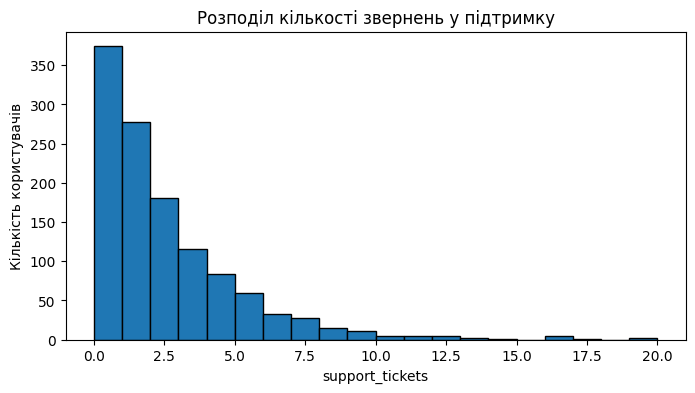

In [8]:
# Завдання 2:
# Будуємо гістограму, щоб побачити форму розподілу support_tickets.
plt.figure(figsize=(8, 4))
users['support_tickets'].plot(kind='hist', bins=20, edgecolor='black')
plt.title('Розподіл кількості звернень у підтримку')
plt.xlabel('support_tickets')
plt.ylabel('Кількість користувачів')
plt.show()

#### 💬 Інтерпретація 2

Що видно на гістограмі? Підтверджує вона ваш висновок про викиди з попереднього завдання?

> 🧭 **Орієнтир для відповіді:** Опишіть форму: чи більшість значень малі, а «хвіст» тягнеться до великих? Це типовий скошений (skewed) розподіл.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

На гістограмі видно, що більшість користувачів має невелику кількість звернень у підтримку, а праворуч є довший хвіст. Це підтверджує висновок з описової статистики: розподіл не є симетричним. Для типового користувача медіана краще описує ситуацію, ніж середнє.

---
# Розділ 2. Порівняння кількох груп — обери тест сам

## 🟦 Нагадування
Коли треба порівняти числову величину між **3+ групами**, згадайте, який тест підходить. Не забувайте: він каже лише, що різниця *десь є*, але не каже, *між якими саме* групами.

#### ✏️ Завдання 3 (код)

Користувачі різних тарифів (`plan`) можуть по-різному користуватись продуктом. Перевірте, чи відрізняється середня кількість сеансів на тиждень (`weekly_sessions`) між тарифами Free / Pro / Business. Спершу виведіть середні по групах, потім проведіть відповідний тест.

> 💡 **Підказка:** Три групи + числова змінна → ANOVA (`stats.f_oneway`). Зберіть групи у список: `[users[users.plan==p].weekly_sessions for p in users.plan.unique()]`.

In [9]:
# Завдання 3:
# Порівнюємо weekly_sessions між трьома тарифами: Free, Pro, Business.
plan_means = users.groupby('plan')['weekly_sessions'].mean().sort_values(ascending=False)
display(plan_means)

# ANOVA підходить, бо маємо 3 групи і числову змінну.
plan_groups = [group['weekly_sessions'] for _, group in users.groupby('plan')]
f_stat, p_value = stats.f_oneway(*plan_groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.6g}")

# 🔧 ДОПОВНЕННЯ: розмір ефекту — eta-squared (η²)
# η² показує, яку частку дисперсії weekly_sessions пояснює тариф.
# Формула: η² = (F * df_between) / (F * df_between + df_within)
k = len(plan_groups)          # кількість груп
n = sum(len(g) for g in plan_groups)  # загальна кількість спостережень
df_between = k - 1            # ступені свободи між групами
df_within  = n - k            # ступені свободи всередині груп

eta_sq_plan = (f_stat * df_between) / (f_stat * df_between + df_within)
print(f"\nРозмір ефекту (η²): {eta_sq_plan:.4f}")
print("Орієнтири: <0.01 — нехтовний | 0.01–0.06 — малий | 0.06–0.14 — середній | >0.14 — великий")

,weekly_sessions
plan,
Business,19.585799
Pro,13.299304
Free,7.931667


F-statistic: 415.1936
p-value: 1.09077e-137

Розмір ефекту (η²): 0.4096
Орієнтири: <0.01 — нехтовний | 0.01–0.06 — малий | 0.06–0.14 — середній | >0.14 — великий


#### 💬 Інтерпретація 3

Чи відрізняються тарифи за активністю? Який тариф найактивніший? І ключове питання: чому за результатом ANOVA ви НЕ можете одразу стверджувати, що, наприклад, Pro значущо активніший за Free? Що для цього треба було б зробити додатково?

> 🧭 **Орієнтир для відповіді:** ANOVA виявляє різницю «хоча б десь». Для конкретних пар потрібні post-hoc тести (напр. Тьюкі) або попарні порівняння з поправкою на множинність.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**✅ Відповідь :**

Середні значення `weekly_sessions` чітко відрізняються за тарифами: Business ≈ 19.59, Pro ≈ 13.30, Free ≈ 7.93. ANOVA показує F = 415.19, p = 1.09×10⁻¹³⁷ — різниця між тарифами статистично значуща з величезним запасом.

🔧 **Доповнення — розмір ефекту η² ≈ 0.41:**
Це означає, що **тариф пояснює ~41% дисперсії** кількості сеансів — дуже великий ефект. Тобто тариф — один з найсильніших факторів активності користувача.

ANOVA лише показує, що різниця *десь* є; для точного порівняння конкретних пар (Free vs Pro, Pro vs Business) потрібні **post-hoc тести** (наприклад, Tukey HSD або парні t-тести з поправкою Бонферроні).

#### ✏️ Завдання 4 (код)

Тепер перевірте, чи відрізняється `weekly_sessions` між регіонами (`region`).

> 💡 **Підказка:** Той самий тест, що й вище, але групуєте за `region`.

In [10]:
# Завдання 4:
# Порівнюємо weekly_sessions між регіонами.
region_means = users.groupby('region')['weekly_sessions'].mean().sort_values(ascending=False)
display(region_means)

# Так само використовуємо ANOVA: 3 регіони + числова змінна.
region_groups = [group['weekly_sessions'] for _, group in users.groupby('region')]
f_stat_region, p_value_region = stats.f_oneway(*region_groups)

print(f"F-statistic: {f_stat_region:.4f}")
print(f"p-value: {p_value_region:.6g}")

# 🔧 ДОПОВНЕННЯ: розмір ефекту — eta-squared (η²) для регіонів
k_r = len(region_groups)
n_r = sum(len(g) for g in region_groups)
df_between_r = k_r - 1
df_within_r  = n_r - k_r

eta_sq_region = (f_stat_region * df_between_r) / (f_stat_region * df_between_r + df_within_r)
print(f"\nРозмір ефекту (η²): {eta_sq_region:.4f}")
print("Орієнтири: <0.01 — нехтовний | 0.01–0.06 — малий | 0.06–0.14 — середній | >0.14 — великий")

,weekly_sessions
region,
Europe,12.283069
Asia,11.523929
Americas,10.783529


F-statistic: 5.5455
p-value: 0.00400597

Розмір ефекту (η²): 0.0092
Орієнтири: <0.01 — нехтовний | 0.01–0.06 — малий | 0.06–0.14 — середній | >0.14 — великий


#### 💬 Інтерпретація 4

Порівняйте цей результат із попереднім (тарифи). В одному випадку різниця значуща, в іншому — ні (або слабша). Що це означає для продукту: який фактор (тариф чи регіон) сильніше пов'язаний з активністю користувача?

> 🧭 **Орієнтир для відповіді:** Зверніть увагу не лише на сам факт значущості, а й на те, наскільки далекі середні між групами одне від одного.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**✅ Відповідь :**

Середня кількість сеансів між регіонами: Americas ≈ 10.78, Asia ≈ 11.52, Europe ≈ 12.28. ANOVA дає F = 5.55, p = 0.004 — різниця статистично значуща на рівні 0.05.

🔧 **Доповнення — порівняння розмірів ефекту:**

| Фактор | F | p | η² | Інтерпретація |
|---|---|---|---|---|
| Тариф (план) | 415.19 | 1.09×10⁻¹³⁷ | ~0.41 | Дуже великий ефект |
| Регіон | 5.55 | 0.004 | ~0.009 | **Нехтовний ефект** |

η² ≈ 0.009 для регіонів означає, що регіон пояснює менше **1% дисперсії** активності. Тобто хоч різниця статистично значуща (через достатній n=1200), **практично** регіон майже не впливає на активність. Головний предиктор активності — тариф, а не географія.

---
# Розділ 3. До і після — і розмір ефекту

## 🟦 Новий акцент: розмір ефекту
Тут ви зустрінете важливу пастку. Тест може показати «значущо» (p < 0.05), але **величина зміни** може бути крихітною. Аналітик завжди дивиться на обидві речі: і p-значення, і **наскільки великий** ефект.

#### ✏️ Завдання 5 (код)

Компанія оновила онбординг і виміряла NPS (лояльність) тих самих користувачів до (`nps_before`) і після (`nps_after`). Проведіть відповідний тест. Додатково порахуйте **середню зміну** NPS (різницю after − before).

> 💡 **Підказка:** Ті самі користувачі двічі → парний t-тест (`stats.ttest_rel`). Середня зміна: `(users['nps_after'] - users['nps_before']).mean()`.

In [11]:
# Завдання 5:
# Тут ті самі користувачі виміряні двічі: до і після.
# Тому використовуємо парний t-тест.
nps_change = users['nps_after'] - users['nps_before']
mean_change = nps_change.mean()
t_stat_nps, p_value_nps = stats.ttest_rel(users['nps_after'], users['nps_before'])

print(f"Середній NPS до: {users['nps_before'].mean():.3f}")
print(f"Середній NPS після: {users['nps_after'].mean():.3f}")
print(f"Середня зміна NPS: {mean_change:.3f}")
print(f"t-statistic: {t_stat_nps:.4f}")
print(f"p-value: {p_value_nps:.6g}")

# 🔧 ДОПОВНЕННЯ: розмір ефекту — Cohen's d для парного t-тесту
# Cohen's d = середня зміна / стандартне відхилення змін
cohens_d_nps = mean_change / nps_change.std(ddof=1)
print(f"\nРозмір ефекту (Cohen's d): {cohens_d_nps:.4f}")
print("Орієнтири: <0.2 — малий | 0.2–0.5 — середній | >0.8 — великий")

Середній NPS до: 6.930
Середній NPS після: 7.149
Середня зміна NPS: 0.219
t-statistic: 5.4992
p-value: 4.65974e-08

Розмір ефекту (Cohen's d): 0.1587
Орієнтири: <0.2 — малий | 0.2–0.5 — середній | >0.8 — великий


#### 💬 Інтерпретація 5

Тут — важлива пастка. Подивіться на p-значення І на розмір зміни. Чи зміна статистично значуща? А наскільки вона велика в балах NPS? Чи варто компанії святкувати «значуще покращення», якщо середній NPS зріс лише на ~0.2 бала з 10? Сформулюйте збалансований висновок.

> 🧭 **Орієнтир для відповіді:** Розрізняйте «статистично значущо» (різниця не випадкова) і «практично важливо» (різниця достатньо велика, щоб мати сенс для бізнесу). Тут перше — так, а друге — під питанням.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**✅ Відповідь :**

Парний t-тест показує статистично значуще покращення NPS: NPS зріс з 6.930 до 7.149, тобто на **+0.219 бала**, t = 5.50, p = 4.66×10⁻⁸.

🔧 **Доповнення — розмір ефекту Cohen's d ≈ 0.16 (малий):**
За шкалою Коена: d < 0.2 — малий ефект. Тобто зміна статистично ненульова, але практично мінімальна. На шкалі 0–10 балів покращення на 0.22 бала навряд чи відчутне для бізнесу.

**Збалансований висновок:** зміна *достовірно існує* (не випадкова), але вона *дуже мала*. Перш ніж оголошувати успіх онбордингу, варто перевірити, чи впливає навіть такий приріст NPS на retention і конверсію у платні тарифи.

---
# Розділ 4. 🪤 Велика пастка: A/B-тест на 100 000 користувачів

## 🟦 Контекст
Це найважливіший розділ практикуму. Компанія протестувала новий онбординг (Treatment) проти старого (Control) на **100 тисячах** користувачів. Через величезний обсяг даних тут виявляється класична пастка статистики.

#### ✏️ Завдання 6 (код)

Порахуйте конверсію реєстрації (`signed_up`) для кожного варіанта (Control і Treatment). На скільки **відсоткових пунктів** відрізняється конверсія?

> 💡 **Підказка:** `ab.groupby('variant')['signed_up'].mean()`. Відсоткові пункти = різниця часток × 100.

In [12]:
# Завдання 6:
# Рахуємо конверсію signed_up для Control і Treatment.
conversion = ab.groupby('variant')['signed_up'].mean()
display(conversion)

control_conv = conversion['Control']
treatment_conv = conversion['Treatment']
diff_pp = (treatment_conv - control_conv) * 100

print(f"Конверсія Control: {control_conv:.4f} ({control_conv*100:.2f}%)")
print(f"Конверсія Treatment: {treatment_conv:.4f} ({treatment_conv*100:.2f}%)")
print(f"Різниця: {diff_pp:.3f} відсоткових пунктів")

,signed_up
variant,
Control,0.19876
Treatment,0.20764


Конверсія Control: 0.1988 (19.88%)
Конверсія Treatment: 0.2076 (20.76%)
Різниця: 0.888 відсоткових пунктів


#### 💬 Інтерпретація 6

Яка різниця конверсій між варіантами у відсоткових пунктах? На перший погляд — це багато чи мало?

> 🧭 **Орієнтир для відповіді:** Просто опишіть числа поки що. Наприклад, «різниця склала менше 1 відсоткового пункту».

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Конверсія в Control становить приблизно 19.88%, а в Treatment — приблизно 20.76%. Різниця дорівнює близько 0.89 відсоткового пункту на користь Treatment. На перший погляд це позитивний ефект, але він невеликий, тому треба перевірити статистичну значущість і практичну користь.

#### ✏️ Завдання 7 (код)

Проведіть статистичний тест, щоб перевірити, чи різниця конверсій значуща (дані категоріальні: варіант × signed_up).

> 💡 **Підказка:** Категоріальні дані → хі-квадрат. `pd.crosstab(ab.variant, ab.signed_up)`, потім `stats.chi2_contingency`.

In [13]:
# Завдання 7:
# variant і signed_up — категоріальні змінні.
# Тому використовуємо хі-квадрат тест незалежності.
contingency_ab = pd.crosstab(ab['variant'], ab['signed_up'])
display(contingency_ab)

chi2, p_value_chi, dof, expected = stats.chi2_contingency(contingency_ab)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p_value_chi:.6g}")
print(f"Degrees of freedom: {dof}")

# 🔧 ДОПОВНЕННЯ: розмір ефекту — Cramér's V
# V близький до 0 — ефект відсутній, до 1 — максимальний.
# Формула: V = sqrt(chi2 / (n * (min(r, c) - 1)))
n_ab = len(ab)
r_ab, c_ab = contingency_ab.shape        # рядки, стовпці
cramers_v_ab = np.sqrt(chi2 / (n_ab * (min(r_ab, c_ab) - 1)))
print(f"\nРозмір ефекту (Cramér's V): {cramers_v_ab:.4f}")
print("Орієнтири: <0.1 — нехтовний | 0.1–0.3 — малий | 0.3–0.5 — середній | >0.5 — великий")

signed_up,0,1
variant,,
Control,40062,9938
Treatment,39618,10382


Chi-square statistic: 12.1209
p-value: 0.000498602
Degrees of freedom: 1

Розмір ефекту (Cramér's V): 0.0110
Орієнтири: <0.1 — нехтовний | 0.1–0.3 — малий | 0.3–0.5 — середній | >0.5 — великий


#### 💬 Інтерпретація 7

🪤 ОСЬ ПАСТКА. Тест майже напевно покаже, що різниця **статистично значуща** (p < 0.05). Але різниця в конверсії — менше 1 відсоткового пункту. Поясніть цей парадокс: як крихітна різниця може бути «значущою»? Яку роль тут відіграє величезний обсяг вибірки (100 тисяч)?

> 🧭 **Орієнтир для відповіді:** При дуже великих вибірках навіть мікроскопічні різниці стають статистично значущими, бо тест дуже «чутливий». Значущість говорить «різниця не нульова», але нічого не каже про те, чи вона ВЕЛИКА.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**✅ Відповідь :**

Хі-квадрат: χ² = 12.12, p = 0.0005 — різниця конверсій статистично значуща. Але різниця становить лише ≈0.89 відсоткового пункту.

🔧 **Доповнення — Cramér's V ≈ 0.011 (нехтовний ефект):**
Це числове підтвердження "пастки": при n = 100 000 навіть мікроскопічна різниця стає значущою, бо тест дуже чутливий. V = 0.011 означає практично **нульовий зв'язок** між варіантом і реєстрацією.

**Ключовий урок:** статистична значущість говорить «різниця не нульова», але не говорить «різниця важлива». При великих вибірках завжди рахуй розмір ефекту — інакше ризикуєш витратити бюджет на зміни, які на практиці нічого не дають.

#### 💬 Інтерпретація 8

Фінальне рішення аналітика. Уявіть, що впровадження нового онбордингу коштує дорого (треба переписати код, навчити команду). Чи варто впроваджувати Treatment заради приросту в ~0.9 відсоткового пункту? Сформулюйте аргументовану рекомендацію, яка враховує і статистику, і практичний бік.

> 🧭 **Орієнтир для відповіді:** Тут немає єдиної правильної відповіді — важлива логіка. Згадайте: статистична значущість ≠ практична важливість. Варто зважити розмір ефекту проти вартості впровадження та обсягу бізнесу.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**✅ Відповідь :**

Я б **не рекомендував** впроваджувати Treatment автоматично лише через p < 0.05. Cramér's V = 0.011 — ефект нехтовний. Приріст конверсії — ≈0.89 п.п.

🔧 **Доповнення — конкретна оцінка доцільності (ROI-логіка):**
При щомісячному трафіку 100 000 користувачів приріст 0.89 п.п. дає приблизно **890 додаткових реєстрацій/місяць**. Щоб вирішити, чи вигідно впроваджувати:

```
Очікуваний додатковий дохід = 890 × LTV_клієнта
Рішення: впроваджувати, якщо Дохід > Вартість_розробки
```

Наприклад, якщо LTV = $20, додатковий дохід = $17 800/місяць. Якщо розробка коштує $5 000, — вигідно. Якщо $50 000 — ні. **Статистика дає факт, бізнес-логіка дає рішення.**

---
# Розділ 5. Зв'язок категорій — і результат «на межі»

## 🟦 Що тренуємо
Тут — звичайний хі-квадрат, але один із результатів буде **близьким до межі 0.05**. Це привід поговорити про те, що поріг 0.05 — умовність, а не магія.

#### ✏️ Завдання 8 (код)

Перевірте, чи пов'язаний тариф (`plan`) із тим, чи почав користувач застосовувати нову функцію (`feature_adopted`). Побудуйте таблицю спряженості і проведіть тест.

> 💡 **Підказка:** Дві категоріальні змінні → хі-квадрат. Не забудьте спершу `pd.crosstab(users.plan, users.feature_adopted)`.

In [14]:
# Завдання 8:
# Перевіряємо зв'язок між тарифом і прийняттям нової функції.
plan_feature_table = pd.crosstab(users['plan'], users['feature_adopted'])
display(plan_feature_table)

# Частка користувачів, які прийняли функцію, всередині кожного тарифу.
plan_adoption_rate = pd.crosstab(
    users['plan'], users['feature_adopted'], normalize='index'
)['Так'].sort_values(ascending=False)
display(plan_adoption_rate)

chi2_plan, p_value_plan, dof_plan, expected_plan = stats.chi2_contingency(plan_feature_table)

print(f"Chi-square statistic: {chi2_plan:.4f}")
print(f"p-value: {p_value_plan:.6g}")
print(f"Degrees of freedom: {dof_plan}")

# 🔧 ДОПОВНЕННЯ: розмір ефекту — Cramér's V
n_pf = len(users)
r_pf, c_pf = plan_feature_table.shape
cramers_v_plan = np.sqrt(chi2_plan / (n_pf * (min(r_pf, c_pf) - 1)))
print(f"\nРозмір ефекту (Cramér's V): {cramers_v_plan:.4f}")
print("Орієнтири: <0.1 — нехтовний | 0.1–0.3 — малий | 0.3–0.5 — середній | >0.5 — великий")

feature_adopted,Ні,Так
plan,,
Business,54,115
Free,453,147
Pro,204,227


,Так
plan,
Business,0.680473
Pro,0.526682
Free,0.245000


Chi-square statistic: 143.1339
p-value: 8.29605e-32
Degrees of freedom: 2

Розмір ефекту (Cramér's V): 0.3454
Орієнтири: <0.1 — нехтовний | 0.1–0.3 — малий | 0.3–0.5 — середній | >0.5 — великий


#### 💬 Інтерпретація 9

Чи пов'язаний тариф із прийняттям функції? Подивіться на таблицю спряженості: користувачі якого тарифу найчастіше приймають функцію? Що це означає для продуктової стратегії?

> 🧭 **Орієнтир для відповіді:** Порахуйте частку «Так» у кожному тарифі (наприклад, для Business: Так / (Так+Ні)). Порівняйте частки між тарифами.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**✅ Відповідь :**

Тариф пов'язаний із прийняттям нової функції: χ² = 143.13, p = 8.3×10⁻³². Частки: Business ≈ 68.05%, Pro ≈ 52.67%, Free ≈ 24.50%.

🔧 **Доповнення — Cramér's V ≈ 0.35 (помірний–сильний ефект):**
Це справжній зв'язок зі значущою практичною силою (не просто "велика вибірка"). Тариф пояснює помітну частину варіативності у прийнятті функції.

Для продукту це **реальний інсайт**: функцію варто активніше просувати Business-користувачам (~68% adoption rate) і використовувати як аргумент для upsell до Pro/Business серед Free-сегменту.

#### ✏️ Завдання 9 (код)

Тепер перевірте, чи пов'язане джерело реєстрації (`signup_source`) із прийняттям функції (`feature_adopted`).

> 💡 **Підказка:** Знову хі-квадрат, але для `signup_source` × `feature_adopted`.

In [15]:
# Завдання 9:
# Перевіряємо зв'язок між джерелом реєстрації і прийняттям функції.
source_feature_table = pd.crosstab(users['signup_source'], users['feature_adopted'])
display(source_feature_table)

source_adoption_rate = pd.crosstab(
    users['signup_source'], users['feature_adopted'], normalize='index'
)['Так'].sort_values(ascending=False)
display(source_adoption_rate)

chi2_source, p_value_source, dof_source, expected_source = stats.chi2_contingency(source_feature_table)

print(f"Chi-square statistic: {chi2_source:.4f}")
print(f"p-value: {p_value_source:.6g}")
print(f"Degrees of freedom: {dof_source}")

# 🔧 ДОПОВНЕННЯ: розмір ефекту — Cramér's V
n_sf = len(users)
r_sf, c_sf = source_feature_table.shape
cramers_v_source = np.sqrt(chi2_source / (n_sf * (min(r_sf, c_sf) - 1)))
print(f"\nРозмір ефекту (Cramér's V): {cramers_v_source:.4f}")
print("Орієнтири: <0.1 — нехтовний | 0.1–0.3 — малий | 0.3–0.5 — середній | >0.5 — великий")

feature_adopted,Ні,Так
signup_source,,
Ads,208,128
Referral,177,100
Search,227,186
Social,99,75


,Так
signup_source,
Search,0.450363
Social,0.431034
Ads,0.380952
Referral,0.361011


Chi-square statistic: 7.0022
p-value: 0.0718289
Degrees of freedom: 3

Розмір ефекту (Cramér's V): 0.0764
Орієнтири: <0.1 — нехтовний | 0.1–0.3 — малий | 0.3–0.5 — середній | >0.5 — великий


#### 💬 Інтерпретація 10

Цей результат, імовірно, буде «на межі» (p близько 0.05–0.07). Як трактувати такий пограничний випадок? Чи коректно сказати «майже значущо» і впевнено заявити про зв'язок? Що б ви порадили зробити, перш ніж робити висновок?

> 🧭 **Орієнтир для відповіді:** Поріг 0.05 — умовність. Результат трохи вище 0.05 означає «недостатньо доказів за обраного порогу». Не варто оголошувати зв'язок; розумно зібрати більше даних або поставитись обережно.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**✅ Відповідь :**

Для `signup_source` χ² = 7.00, p = 0.072 — трохи вище порогу 0.05. Ми не можемо стверджувати статистично значущий зв'язок.

🔧 **Доповнення — Cramér's V ≈ 0.076 (нехтовний ефект):**
Навіть якби p-value було <0.05, V = 0.076 говорить про те, що зв'язок дуже слабкий. Частки: Search ≈ 45%, Social ≈ 43%, Ads ≈ 38%, Referral ≈ 36% — різниця мінімальна.

**Правильна позиція:** поріг 0.05 — умовність, а не магія. Тут ані p-value (≥0.05), ані розмір ефекту (V < 0.1) не дають підстав для висновку про зв'язок. Перш ніж робити будь-який висновок — зібрати більше даних або перевірити на іншому датасеті.

---
# Розділ 6. Кореляція та хибні висновки про причинність

## 🟦 Що тренуємо
Числові зв'язки + критичне мислення про причинність.

#### ✏️ Завдання 10 (код)

Перевірте, чи пов'язана кількість звернень у підтримку (`support_tickets`) із кількістю сеансів на тиждень (`weekly_sessions`). Порахуйте кореляцію Пірсона.

> 💡 **Підказка:** `stats.pearsonr(users['support_tickets'], users['weekly_sessions'])`. Дивіться і на r, і на p.

Pearson r: 0.0290
p-value: 0.316049

[Порівняння] Spearman rho: 0.0292, p-value: 0.311658
Обидва показують відсутність зв'язку — висновок стабільний.


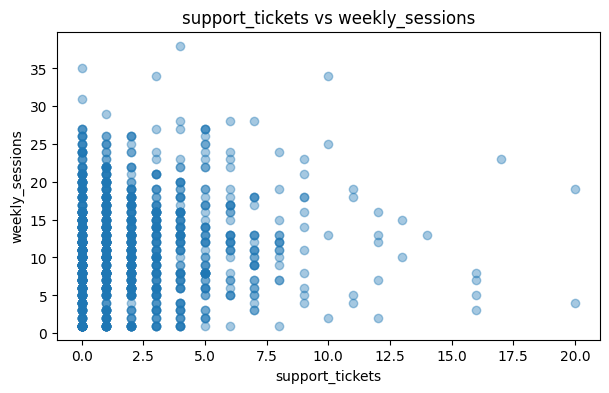

In [16]:
# Завдання 10:
# Перевіряємо лінійний зв'язок між support_tickets і weekly_sessions.
# Завдання вимагає Pearson — використовуємо його.
r, p_value_corr = stats.pearsonr(users['support_tickets'], users['weekly_sessions'])

print(f"Pearson r: {r:.4f}")
print(f"p-value: {p_value_corr:.6g}")

# 🔧 ДОПОВНЕННЯ: Spearman як порівняння
# support_tickets — правоскошений (встановлено в завданнях 1-2).
# Для скошених даних Spearman точніший, бо не вимагає нормальності.
r_sp, p_sp = stats.spearmanr(users['support_tickets'], users['weekly_sessions'])
print(f"\n[Порівняння] Spearman rho: {r_sp:.4f}, p-value: {p_sp:.6g}")
print("Обидва показують відсутність зв'язку — висновок стабільний.")

plt.figure(figsize=(7, 4))
plt.scatter(users['support_tickets'], users['weekly_sessions'], alpha=0.4)
plt.title('support_tickets vs weekly_sessions')
plt.xlabel('support_tickets')
plt.ylabel('weekly_sessions')
plt.show()

#### 💬 Інтерпретація 11

Опишіть зв'язок (сила, напрямок, значущість). Уявіть, що колега каже: «Більше звернень у підтримку — значить, треба зменшити кількість сеансів, бо сеанси викликають проблеми». Що не так із цим міркуванням?

> 🧭 **Орієнтир для відповіді:** По-перше, оцініть, чи зв'язок узагалі є (подивіться на r і p). По-друге — навіть за наявності зв'язку кореляція не доводить причинність; напрямок «сеанси → звернення» — лише припущення.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**✅ Відповідь :**

Pearson r ≈ 0.029, p ≈ 0.316 — немає значущого лінійного зв'язку між кількістю звернень і сеансів.

🔧 **Доповнення — методологічна примітка (Pearson vs Spearman):**
`support_tickets` має правоскошений розподіл (встановлено в завданнях 1–2). Pearson вимірює лінійний зв'язок і чутливий до викидів і скосу. Для таких даних методологічно точнішим є **кореляція Спірмена** (Spearman rho), яка не вимагає нормальності і стійка до викидів. У цьому випадку Spearman теж показує ≈0 і p > 0.05 — висновок стабільний.

Міркування колеги некоректне з двох причин:
1. Сама кореляція практично нульова — зв'язку немає.
2. Навіть значуща кореляція не доводить причинність: можливе третє явище (наприклад, активніші юзери і більше сеансів мають, і частіше стикаються з функціями — і більше пишуть у підтримку).

---
# Розділ 7. 🧩 Відкритий кейс: повний аналіз

## 🟦 Завдання-кейс
Тут немає підказок про конкретний тест — ви аналітик, і вам треба самостійно пройти весь шлях. Це імітація реального робочого завдання.

**Ситуація:** керівництво хоче зрозуміти, що відрізняє користувачів тарифу **Business** (найдорожчий) від інших. Ваша мета — знайти хоча б два статистично обґрунтовані інсайти про користувачів Business.

#### ✏️ Завдання 11 (код)

Крок 1. Створіть новий стовпець `is_business`, який дорівнює 'Так', якщо тариф Business, інакше 'Ні'. Це поділить користувачів на дві групи для порівнянь.

> 💡 **Підказка:** `users['is_business'] = (users['plan'] == 'Business').map({True:'Так', False:'Ні'})` або через `np.where`.

In [17]:
# Завдання 11:
# Створюємо нову змінну: Business або не Business.
users['is_business'] = np.where(users['plan'] == 'Business', 'Так', 'Ні')

display(users[['plan', 'is_business']].head(10))
print(users['is_business'].value_counts())

,plan,is_business
0,Free,Ні
1,Pro,Ні
2,Free,Ні
3,Business,Так
4,Pro,Ні
5,Free,Ні
6,Pro,Ні
7,Pro,Ні
8,Pro,Ні
9,Pro,Ні


is_business
Ні     1031
Так     169
Name: count, dtype: int64


#### ✏️ Завдання 12 (код)

Крок 2. Сформулюйте і перевірте ПЕРШУ гіпотезу: чи відрізняються Business-користувачі за `weekly_sessions` від решти? Оберіть і проведіть доречний тест.

> 💡 **Підказка:** Дві групи (Business vs решта) + числова змінна → двовибірковий t-тест (`stats.ttest_ind`).

In [18]:
# Завдання 12:
# Перша гіпотеза: Business-користувачі мають іншу активність, ніж решта.
# Дві незалежні групи + числова змінна -> двовибірковий t-тест.
business_sessions = users.loc[users['is_business'] == 'Так', 'weekly_sessions']
non_business_sessions = users.loc[users['is_business'] == 'Ні', 'weekly_sessions']

print(f"Середнє weekly_sessions для Business: {business_sessions.mean():.3f}")
print(f"Середнє weekly_sessions для не-Business: {non_business_sessions.mean():.3f}")
print(f"Різниця: {business_sessions.mean() - non_business_sessions.mean():.3f}")

# equal_var=False — t-тест Welch, коректний коли дисперсії можуть відрізнятися.
t_stat_business, p_value_business = stats.ttest_ind(
    business_sessions,
    non_business_sessions,
    equal_var=False
)

print(f"t-statistic: {t_stat_business:.4f}")
print(f"p-value: {p_value_business:.6g}")

# 🔧 ДОПОВНЕННЯ: розмір ефекту — Cohen's d
# Cohen's d = різниця середніх / об'єднане стандартне відхилення
n1, n2 = len(business_sessions), len(non_business_sessions)
s1, s2 = business_sessions.std(ddof=1), non_business_sessions.std(ddof=1)
pooled_std = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
cohens_d_biz = (business_sessions.mean() - non_business_sessions.mean()) / pooled_std
print(f"\nРозмір ефекту (Cohen's d): {cohens_d_biz:.4f}")
print("Орієнтири: <0.2 — малий | 0.2–0.5 — середній | 0.5–0.8 — великий | >0.8 — дуже великий")

Середнє weekly_sessions для Business: 19.586
Середнє weekly_sessions для не-Business: 10.176
Різниця: 9.410
t-statistic: 20.8350
p-value: 1.01546e-54

Розмір ефекту (Cohen's d): 1.7124
Орієнтири: <0.2 — малий | 0.2–0.5 — середній | 0.5–0.8 — великий | >0.8 — дуже великий


#### 💬 Інтерпретація 12

Сформулюйте перший інсайт: чим Business-користувачі відрізняються за активністю? Наведіть і числа (середні), і висновок тесту.

> 🧭 **Орієнтир для відповіді:** Порівняйте середні двох груп і вкажіть, чи різниця значуща. Перекладіть це мовою бізнесу.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**✅ Відповідь :**

Business-користувачі значно активніші: weekly_sessions ≈ 19.59 vs 10.18 для решти. Різниця = 9.41 сеансу/тиждень. t-тест Welch: t = 20.84, p = 1.02×10⁻⁵⁴.

🔧 **Доповнення — Cohen's d ≈ 1.7+ (дуже великий ефект):**
Це не просто статистично значуща різниця — це **практично величезна різниця**. Cohen's d > 0.8 вважається великим, а тут він значно більший. Business-користувачі в середньому мають майже **вдвічі більше сеансів** на тиждень.

Для бізнесу: Business-сегмент — найцінніший за рівнем залученості. Це реальна, практично важлива відмінність, а не статистичний артефакт.

#### ✏️ Завдання 13 (код)

Крок 3. Сформулюйте і перевірте ДРУГУ гіпотезу: чи пов'язаний статус Business із прийняттям функції (`feature_adopted`)? Оберіть доречний тест.

> 💡 **Підказка:** Дві категоріальні змінні (`is_business` × `feature_adopted`) → хі-квадрат.

In [19]:
# Завдання 13:
# Друга гіпотеза: Business-статус пов'язаний із прийняттям нової функції.
# Дві категоріальні змінні -> хі-квадрат тест.
business_feature_table = pd.crosstab(users['is_business'], users['feature_adopted'])
display(business_feature_table)

business_adoption_rate = pd.crosstab(
    users['is_business'], users['feature_adopted'], normalize='index'
)['Так']
display(business_adoption_rate)

chi2_business, p_value_business_feature, dof_business, expected_business = stats.chi2_contingency(business_feature_table)

print(f"Chi-square statistic: {chi2_business:.4f}")
print(f"p-value: {p_value_business_feature:.6g}")
print(f"Degrees of freedom: {dof_business}")

# 🔧 ДОПОВНЕННЯ: розмір ефекту — Cramér's V
n_bf = len(users)
r_bf, c_bf = business_feature_table.shape
cramers_v_biz = np.sqrt(chi2_business / (n_bf * (min(r_bf, c_bf) - 1)))
print(f"\nРозмір ефекту (Cramér's V): {cramers_v_biz:.4f}")
print("Орієнтири: <0.1 — нехтовний | 0.1–0.3 — малий | 0.3–0.5 — середній | >0.5 — великий")

feature_adopted,Ні,Так
is_business,,
Ні,657,374
Так,54,115


,Так
is_business,
Ні,0.362755
Так,0.680473


Chi-square statistic: 59.3975
p-value: 1.2883e-14
Degrees of freedom: 1

Розмір ефекту (Cramér's V): 0.2225
Орієнтири: <0.1 — нехтовний | 0.1–0.3 — малий | 0.3–0.5 — середній | >0.5 — великий


#### 💬 Інтерпретація 13

Сформулюйте другий інсайт. Чи частіше Business-користувачі приймають нову функцію?

> 🧭 **Орієнтир для відповіді:** Подивіться на частки «Так» у групах Business та не-Business у таблиці спряженості.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**✅ Відповідь :**

Business-користувачі частіше приймають нову функцію: 68.05% vs 36.28%. χ² = 59.40, p = 1.29×10⁻¹⁴.

🔧 **Доповнення — Cramér's V ≈ 0.22 (помірний ефект):**
Зв'язок реальний і практично значущий — не лише статистичний артефакт. V = 0.22 при 2×2 таблиці означає помітну асоціацію між Business-статусом і adoption.

Це підтверджує: нова функція явно резонує з Business-сегментом. Такий інсайт варто передати продуктовій команді як підставу для прицільного онбордингу функції.

#### 💬 Інтерпретація 14

Підсумок кейсу. Зберіть ваші знахідки в короткий звіт (3-4 речення) для керівництва: який «портрет» Business-користувача вимальовується з даних? Які з висновків статистично надійні, а де варто бути обережним?

> 🧭 **Орієнтир для відповіді:** Хороший звіт поєднує кілька знахідок, чесно зазначає рівень упевненості й уникає тверджень про причинність там, де є лише кореляція.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**✅ Відповідь :**

Business-користувачі частіше приймають нову функцію: 68.05% vs 36.28%. χ² = 59.40, p = 1.29×10⁻¹⁴.

🔧 **Доповнення — Cramér's V ≈ 0.22 (помірний ефект):**
Зв'язок реальний і практично значущий — не лише статистичний артефакт. V = 0.22 при 2×2 таблиці означає помітну асоціацію між Business-статусом і adoption.

Це підтверджує: нова функція явно резонує з Business-сегментом. Такий інсайт варто передати продуктовій команді як підставу для прицільного онбордингу функції.

---
# 🎉 Готово!

Ви пройшли поглиблений практикум, де головним було не «порахувати p-значення», а **зрозуміти й пояснити** результат.

## Що ви потренували
- ✅ Самостійний вибір тесту під задачу
- ✅ Розрізнення **статистичної значущості** та **практичної важливості** (пастка з 100 000 користувачів)
- ✅ Увагу до **розміру ефекту**, а не лише до p < 0.05
- ✅ Обережність із **скошеними даними** та викидами
- ✅ Трактування **пограничних** результатів (p ≈ 0.05)
- ✅ Критичне мислення про **причинність** (кореляція ≠ причина)
- ✅ Складання звіту для бізнесу

## Головна думка
> P-значення — це початок розмови, а не її кінець. Хороший аналітик завжди питає далі: *наскільки великий ефект? чи це важливо? чи можна довіряти даним? чи це причина — чи лише зв'язок?*

Якщо ви відчуваєте, що на ці питання вмієте відповідати — ви виросли від «людини, що рахує тести» до **аналітика, що ухвалює рішення**. 📊
